# Quantum dot modes: a finite lattice as a particle in a box
Cutting a finite flake out of an infinite lattice (a "quantum dot") turns the continuous band structure into a discrete spectrum of confined modes, exactly like the textbook particle-in-a-box problem — but now on a lattice, with the flake's shape and symmetry setting the pattern and degeneracies of the standing waves. We build a square quantum dot and look at the real-space shape of its lowest-energy confined states.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry

### Build a finite 20x20 square-lattice flake
Setting `dimensionality = 0` after taking the supercell turns off periodicity: the flake becomes an isolated, finite system.
$$ H = \sum_{\langle ij \rangle} c^\dagger_i c_j $$

In [2]:
g = geometry.square_lattice() # create the geometry
g = g.get_supercell(20) # create a supercell
g.dimensionality = 0 # set the system zero dimensional
h = g.get_hamiltonian() # create hamiltonian of the system

### Diagonalize the Hamiltonian
Without a Brillouin zone, `get_bands` just returns the discrete eigenvalues (labeled by an index, not by momentum).
$$ H \left | \Psi_n \right \rangle = \epsilon_n \left | \Psi_n \right \rangle $$

In [3]:
(inds,energies) = h.get_bands() # get the eigenenergies
es8 = np.unique(np.round(energies,6))[0:8] # lowest different 8 energies

### At each of those eigenenergies, compute the local density of states
$$\rho (r) =  \text{Im} \left ( \left \langle r \right | (\omega - H +i\delta)^{-1} \left | r \right \rangle \right ) $$
At a non-degenerate eigenenergy this is just $|\Psi_n(r)|^2$: the shape of that confined mode.

In [4]:
ldos_array = [h.get_ldos(e=ei,write=False) for ei in es8] # compute LDOS for the lowest 8 energies

### Plot the local density of states in real space
The ground state is a single central lobe; the next levels come in degenerate pairs with one and two nodal lines, just like the $(n_x,n_y)$ quantum numbers of a 2D particle in a box.

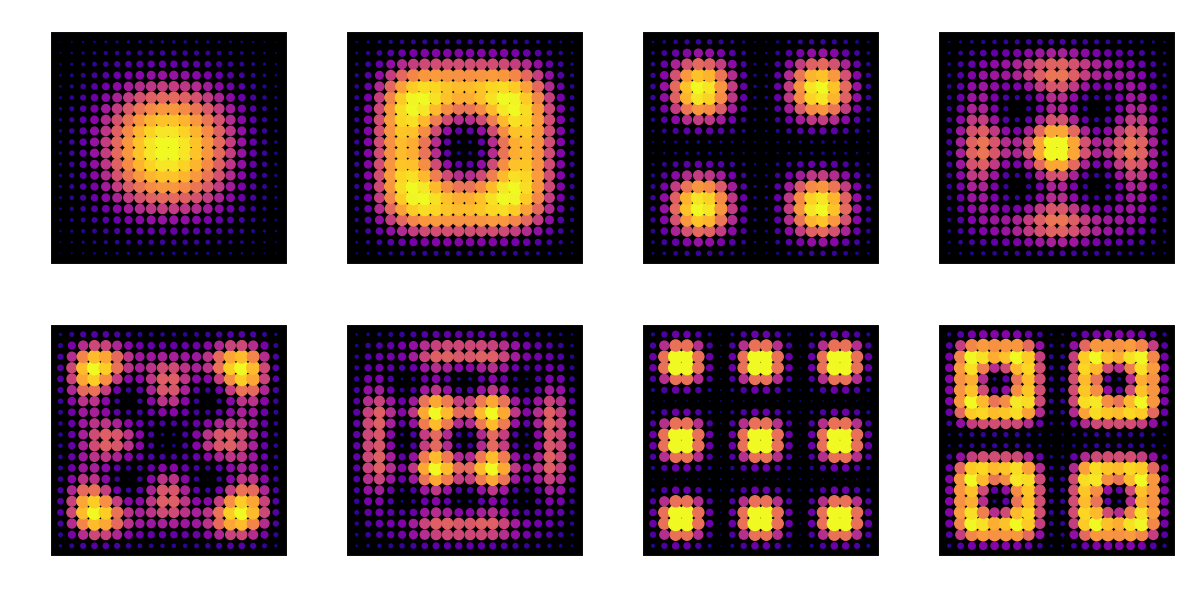

In [5]:
fig = plt.figure(figsize=(12, 6)) # set the right ratio
plt.style.use('dark_background') # use the dark mode
for ip,(x,y,d) in enumerate(ldos_array,start=1): # loop over LDOS maps
    plt.subplot(2,4,ip) # create an individual subplot
    dn = d/np.max(d) # normalize
    plt.scatter(x,y,s=dn*100,c=dn,cmap="plasma")
    plt.title(f"$E={es8[ip-1]:.2f}$")

plt.tight_layout()
plt.show()